In [1]:
#Libraries 

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy
# Text processing
import re
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
import contractions

In [2]:
#Retrieve the dataset without having to import the dataset again

%store -r disneyland_df

In [3]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris


In [4]:
def clean_text_total(text):
    """
    Clean raw text by removing noise.
    
    Steps:
        1. Remove HTML tags (e.g., <p>, <div>, <br>)
        2. Remove URLs (http://, https://, www.)
        3. Remove email addresses
        4. Normalize whitespace (multiple spaces → single space)
    
    Parameters:
        text (str): Raw text string
    
    Returns:
        str: Cleaned text string
    
    Example:
        >>> clean_text("<p>Visit http://example.com or email test@mail.com</p>")
        'Visit or email'
    """
    # Handle missing values
    if pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Step 1: Remove HTML tags
    # Pattern: <anything> where anything doesn't contain >
    text = re.sub(r'<[^>]+>', '', text)
    
    # Step 2: Remove URLs
    # Pattern: http(s):// or www. followed by non-whitespace
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Step 3: Remove email addresses
    # Pattern: something@something.something
    text = re.sub(r'\S+@\S+', '', text)

    #Step 4: Catch any additional HTML that didn't make it through the initial cleaning steps.
    text= BeautifulSoup(text, "html.parser").get_text()
    
    # Step 4: Normalize whitespace
    # Replace multiple spaces/tabs/newlines with single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Expand contractions
    text=contractions.fix(text)

    #Removes Special Characters
    text=re.sub(r'[^a-zA-Z0-9. !?]', ' ', text)
    
    return text

#This function is for the analysis on words themselves instead of as a whole
def remove_punctuation(text):
    text=re.sub(r'[^a-zA-Z0-9 ]', ' ', text)
    return text


In [5]:
disneyland_df['review_cleaned']=disneyland_df['Review_Text'].apply(clean_text_total)

In [33]:
nltk.download('stopwords') #need to download this pre-trained data for using with word tokenizer
#
stop_words_nltk = list(stopwords.words('english')) #define English as the stop words

#Create a new column to store the cleaned text
disneyland_df['clean_review_wo_stopwords']=disneyland_df['review_cleaned'].copy()

#Go through each review and remove any stopwords that exist.
for review in range(0, len(disneyland_df)):
    a = disneyland_df.Review_Text[review].split()
    sentence=[ x for x in a  if x.casefold() not in stop_words_nltk]
    disneyland_df['clean_review_wo_stopwords'][review]=" ".join(sentence)

custom_stopwords = ['disneyland','disney','park','day','time','went','also','really','just']

for review in range(0, len(disneyland_df)):
    a = disneyland_df.clean_review_wo_stopwords[review].split()
    sentence=[ x for x in a  if x.casefold() not in custom_stopwords]
    disneyland_df['clean_review_wo_stopwords'][review]=" ".join(sentence)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ysass\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,If you have ever been to Disneyland anywhere y...,ever anywhere find Hong Kong similar layout wa...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,Its been a while since d last time we visit HK...,since last visit HK .. Yet stay Tomorrowland ....
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,Thanks God it wasn t too hot or too humid when...,Thanks God hot humid visiting otherwise would ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,HK Disneyland is a great compact park. Unfortu...,HK great compact park. Unfortunately quite bit...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around 1...,location city took around 1 hour Kowlon kids l...
...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july 03 and thou...,paris july 03 thought brilliant. visited hotel...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,2 adults and 1 child of 11 visited Disneyland ...,2 adults 1 child 11 visited Paris beginning Fe...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,My eleven year old daughter and myself went to...,eleven year old daughter visit son London deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,This hotel part of the Disneyland Paris compl...,hotel part Paris complex wonderful place famil...


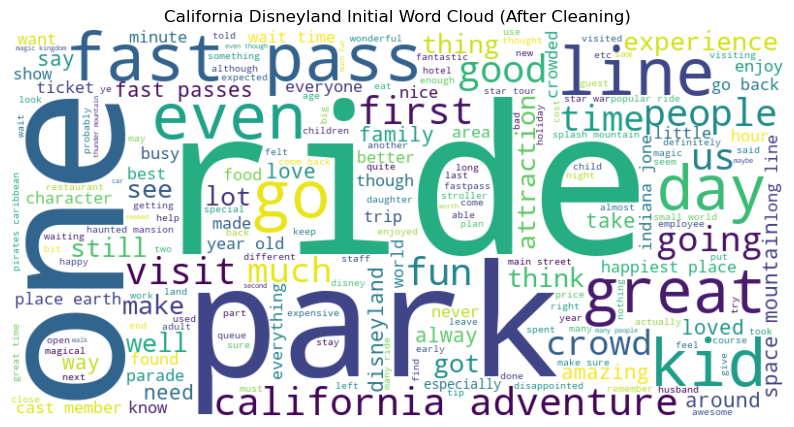

In [19]:
#Break Down the Different Categories
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

from wordcloud import WordCloud, STOPWORDS

text_combined = " ".join(california_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('California Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

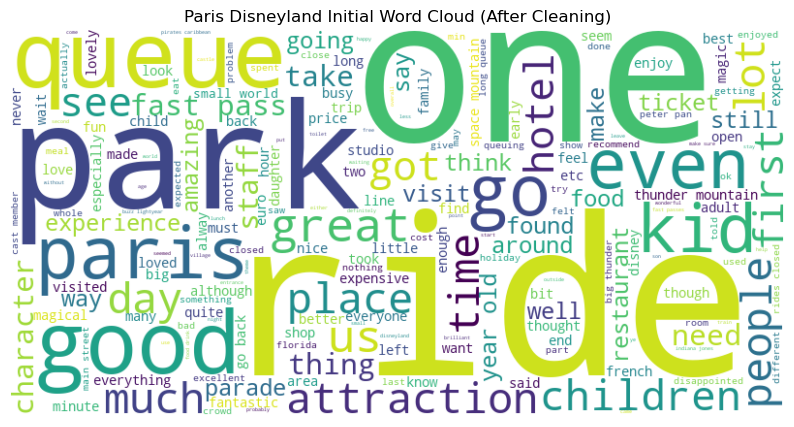

In [21]:
text_combined = " ".join(paris_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Paris Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

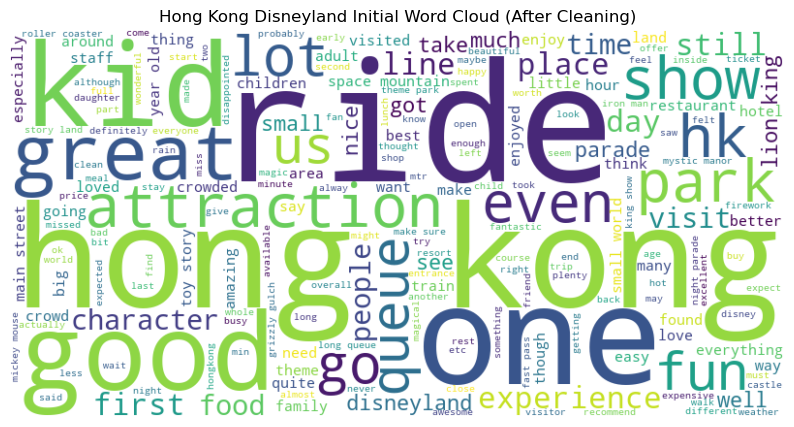

In [22]:
text_combined = " ".join(hong_kong_reviews['clean_review_wo_stopwords'].dropna().str.lower())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_combined)

plt.figure(figsize=(10, 8))
plt.title('Hong Kong Disneyland Initial Word Cloud (After Cleaning)')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [55]:
def most_popular_words(dataframe):
    words=dataframe['clean_review_wo_stopwords'].str.split()
    all_words=words.explode()
    all_words_standard=all_words.str.lower()
    word_counts=all_words_standard.value_counts()
    top_n_words=word_counts.index[:10]
    return top_n_words

In [57]:
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

print(f'The average number of characters in a review (after cleaning) is {disneyland_df['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a California review (after cleaning) is {california_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a Paris review (after cleaning) is {paris_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')
print(f'The average number of characters in a Disneyland review (after cleaning) is {hong_kong_reviews['clean_review_wo_stopwords'].str.len().mean()} characters.')

#2.3.2 Vocabulary
#These reviews contain no emojis, more casual language, language that could be used to heighten emotion (contain emphasis). There are also certain cases where words
#are written in all caps. Depending on the person who wrote it there are some reviews that are more sopisticated in terms of word choice while other people used more 
#simple vocabulary. 

#2.3.3 Common words per class and label
print(f'The top 10 most popular words in California reviews (after cleaning) are {', '.join(most_popular_words(california_reviews))}.')
print(f'The top 10 most popular words in Paris reviews (after cleaning) are {', '.join(most_popular_words(paris_reviews))}.')
print(f'The top 10 most popular words in Hong Kong (after cleaning) reviews are {', '.join(most_popular_words(hong_kong_reviews))}.')

The average number of characters in a review (after cleaning) is 431.51045573893475 characters.
The average number of characters in a California review (after cleaning) is 382.17139029166236 characters.
The average number of characters in a Paris review (after cleaning) is 563.3518708730741 characters.
The average number of characters in a Disneyland review (after cleaning) is 344.24178794178795 characters.
The top 10 most popular words in California reviews (after cleaning) are get, rides, go, one, ride, great, would, fast, place, like.
The top 10 most popular words in Paris reviews (after cleaning) are rides, get, one, go, would, food, good, great, ride, paris.
The top 10 most popular words in Hong Kong (after cleaning) reviews are rides, one, hong, get, go, kids, food, great, place, kong.


In [59]:
# Vocabulary for each group
text_combined_hong_kong = " ".join(hong_kong_reviews['Review_Text'].dropna().str.lower())
text_combined_paris = " ".join(paris_reviews['Review_Text'].dropna().str.lower())
text_combined_california = " ".join(california_reviews['Review_Text'].dropna().str.lower())

individual_words_hong_kong=text_combined_hong_kong.split()
individual_words_paris=text_combined_paris.split()
individual_words_california=text_combined_california.split()


# Get the unique words (vocabulary) using a set
vocabulary_hong_kong = set(individual_words_hong_kong)
vocabulary_paris = set(individual_words_paris)
vocabulary_california = set(individual_words_california)


print("Vocabulary Hong Kong:", vocabulary_hong_kong, '\n')
print("Vocabulary Paris:", vocabulary_paris, '\n')
print("Vocabulary California:", vocabulary_california, '\n')

Vocabulary Hong Kong: {'windows...', 'facts', 'adult.travelling:', 'pretence', 'treehouse).', 'friend', "malaysia's", 'ride.park', 'evident,', 'believing,', 'miniscule', 'grateful', 'homes', 'unimaginative', 'taste.', 'average,', 'breakfast,', '112', 'minnies).', 'jostled', 'smiling', 'muslim,', 'coat', 'more.the', 'helpful', 'friends?', '9th).like', 'quiet!', 'combined.', 'foundtains:', 'crossed', 'sunset,', 'updating.a', 'halloween!', 'budget', '(nobody', 'hkd1000.', '57%', 'complains', 'express..', 'chilkdren.', 'powerbanks', 'properties.getting', 'merriest', '(sentimental', '$168cheese', 'park!', 'following', 'blasters', 'oar', 'prediction.', '(10am)', 'drink:', 'hkd100', 'scenary', 'entertaintment', ')however', 'hahah.', 'reasons,', 'kindniss', '1030', 'synonomous', 'absorbed', 'see)', 'weather),', 'bored', 'same..thanx', 'mytic', 'youself.', 'afterwards.4.', 'practical', 'dvds', 'placards', 'day!an', 'here:https:', 'of...more', 'cafes', 'noise.', 'disneyland!!!', 'factor,', "pers